In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv("/content/House_Rent_Dataset.csv")

print(df.shape)
print(df.columns)
df.head()

(4746, 12)
Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [6]:
data = df.copy()

data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

data = data.drop_duplicates()

print(data.shape)
data.head()

(4746, 12)


,posted_on,bhk,rent,size,floor,area_type,area_locality,city,furnishing_status,tenant_preferred,bathroom,point_of_contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [7]:
print(df.shape)
print(df.columns)

(4746, 12)
Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')


In [8]:
print(data.info())
print("\nMissing values:")
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   posted_on          4746 non-null   object
 1   bhk                4746 non-null   int64 
 2   rent               4746 non-null   int64 
 3   size               4746 non-null   int64 
 4   floor              4746 non-null   object
 5   area_type          4746 non-null   object
 6   area_locality      4746 non-null   object
 7   city               4746 non-null   object
 8   furnishing_status  4746 non-null   object
 9   tenant_preferred   4746 non-null   object
 10  bathroom           4746 non-null   int64 
 11  point_of_contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB
None

Missing values:
posted_on            0
bhk                  0
rent                 0
size                 0
floor                0
area_type            0
area_locality        0


In [9]:
data["rent"] = pd.to_numeric(data["rent"], errors="coerce")
data["size"] = pd.to_numeric(data["size"], errors="coerce")
data["bhk"] = pd.to_numeric(data["bhk"], errors="coerce")
data["bathroom"] = pd.to_numeric(data["bathroom"], errors="coerce")

data = data.dropna(subset=["rent", "size", "bhk", "bathroom"])

data["rent_per_sqft"] = data["rent"] / data["size"].replace(0, np.nan)
data = data.dropna(subset=["rent_per_sqft"])

data["completeness_score"] = data[
    [
        "bhk",
        "rent",
        "size",
        "floor",
        "area_type",
        "area_locality",
        "city",
        "furnishing_status",
        "tenant_preferred",
        "bathroom",
        "point_of_contact",
    ]
].notna().mean(axis=1)

low_rent = data["rent_per_sqft"].quantile(0.15)
high_rent = data["rent_per_sqft"].quantile(0.85)

def assign_review_category(row):
    if row["completeness_score"] < 0.65:
        return "High review required"
    if row["rent_per_sqft"] > high_rent or row["rent_per_sqft"] < low_rent:
        return "Needs review"
    return "Standard review"

data["review_category"] = data.apply(assign_review_category, axis=1)

data[["rent", "size", "rent_per_sqft", "completeness_score", "review_category"]].head()

,rent,size,rent_per_sqft,completeness_score,review_category
0,10000,1100,9.090909,1.0,Needs review
1,20000,800,25.000000,1.0,Standard review
2,17000,1000,17.000000,1.0,Standard review
3,10000,800,12.500000,1.0,Standard review
4,7500,850,8.823529,1.0,Needs review


In [10]:
print("Cleaned dataset shape:", data.shape)

print("\nReview category counts:")
print(data["review_category"].value_counts())

print("\nAverage rent:")
print(round(data["rent"].mean(), 2))

print("\nAverage size:")
print(round(data["size"].mean(), 2))

Cleaned dataset shape: (4746, 15)

Review category counts:
review_category
Standard review    3331
Needs review       1415
Name: count, dtype: int64

Average rent:
34993.45

Average size:
967.49


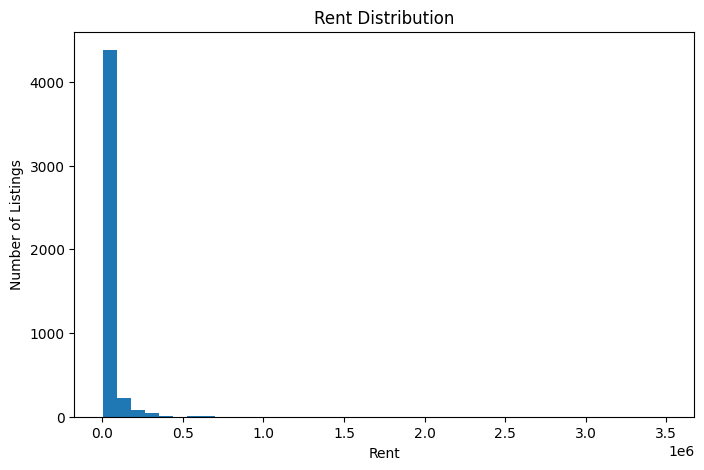

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(data["rent"], bins=40)
plt.title("Rent Distribution")
plt.xlabel("Rent")
plt.ylabel("Number of Listings")
plt.show()

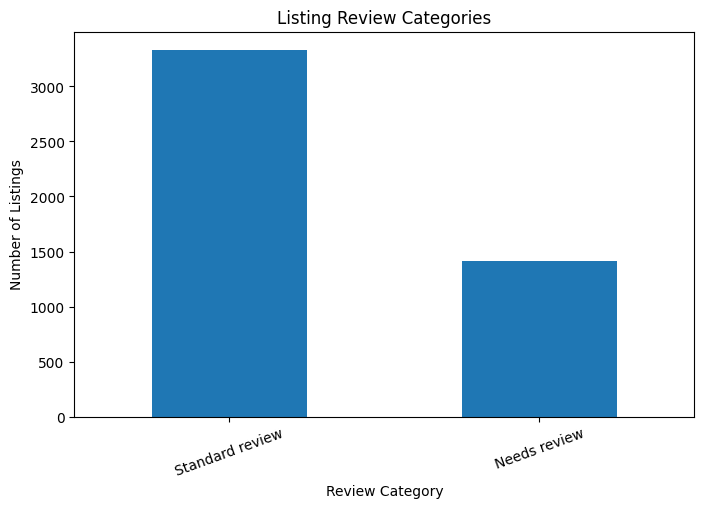

In [12]:
plt.figure(figsize=(8, 5))
data["review_category"].value_counts().plot(kind="bar")
plt.title("Listing Review Categories")
plt.xlabel("Review Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=20)
plt.show()

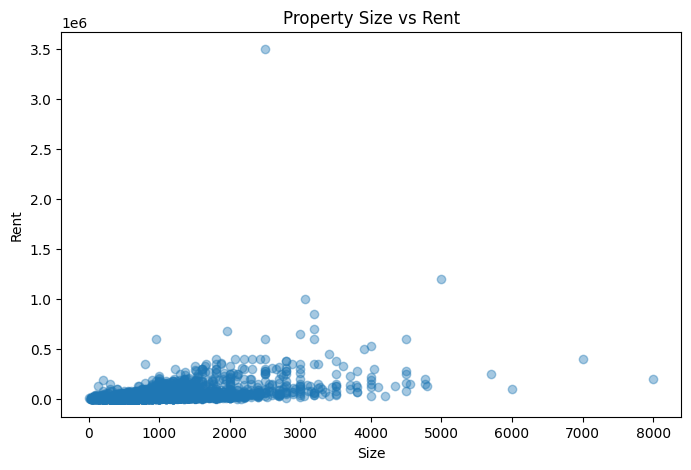

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(data["size"], data["rent"], alpha=0.4)
plt.title("Property Size vs Rent")
plt.xlabel("Size")
plt.ylabel("Rent")
plt.show()

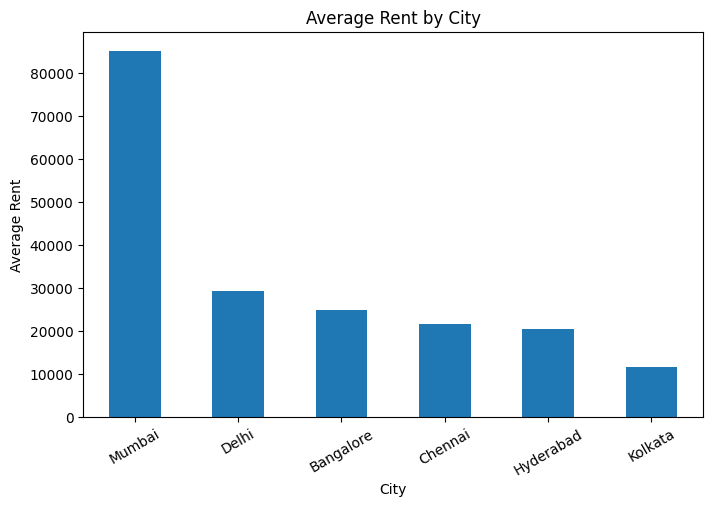

In [14]:
city_rent = data.groupby("city")["rent"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
city_rent.plot(kind="bar")
plt.title("Average Rent by City")
plt.xlabel("City")
plt.ylabel("Average Rent")
plt.xticks(rotation=30)
plt.show()

In [15]:
features = [
    "bhk",
    "size",
    "bathroom",
    "completeness_score",
    "city",
    "area_type",
    "furnishing_status",
    "tenant_preferred",
    "point_of_contact",
]

target_regression = "rent"
target_classification = "review_category"

model_data = data[features + [target_regression, target_classification]].copy()

print(model_data.columns)
model_data.head()

Index(['bhk', 'size', 'bathroom', 'completeness_score', 'city', 'area_type',
       'furnishing_status', 'tenant_preferred', 'point_of_contact', 'rent',
       'review_category'],
      dtype='object')


,bhk,size,bathroom,completeness_score,city,area_type,furnishing_status,tenant_preferred,point_of_contact,rent,review_category
0,2,1100,2,1.0,Kolkata,Super Area,Unfurnished,Bachelors/Family,Contact Owner,10000,Needs review
1,2,800,1,1.0,Kolkata,Super Area,Semi-Furnished,Bachelors/Family,Contact Owner,20000,Standard review
2,2,1000,1,1.0,Kolkata,Super Area,Semi-Furnished,Bachelors/Family,Contact Owner,17000,Standard review
3,2,800,1,1.0,Kolkata,Super Area,Unfurnished,Bachelors/Family,Contact Owner,10000,Standard review
4,2,850,1,1.0,Kolkata,Carpet Area,Unfurnished,Bachelors,Contact Owner,7500,Needs review


In [16]:
X = model_data[features]
y_rent = model_data[target_regression]
y_review = model_data[target_classification]

X_train, X_test, y_rent_train, y_rent_test, y_review_train, y_review_test = train_test_split(
    X,
    y_rent,
    y_review,
    test_size=0.2,
    random_state=42,
    stratify=y_review
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("X columns:", X_train.columns.tolist())
print("Testing rows:", X_test.shape[0])

Training rows: 3796
Testing rows: 950
X columns: ['bhk', 'size', 'bathroom', 'completeness_score', 'city', 'area_type', 'furnishing_status', 'tenant_preferred', 'point_of_contact']
Testing rows: 950


## Model Architecture

This notebook uses a traditional supervised machine learning approach.

Two models are trained:

1. Random Forest Regressor  
   - Used to estimate the expected rental price of a listing.
   - Input features include size, bedrooms, bathrooms, rent per square foot, completeness score, city, furnishing status, area type, tenant preference, and point of contact.

2. Random Forest Classifier  
   - Used to classify each listing into a review category.
   - The review categories are Standard review, Needs review, and High review required.

Because this is not a neural network, there are no layers or activation functions. The model uses decision-tree ensembles. Categorical variables are transformed using one-hot encoding, and Random Forest models are used for both prediction and classification.

In [17]:
categorical_features = [
    "city",
    "area_type",
    "furnishing_status",
    "tenant_preferred",
    "point_of_contact",
]

numeric_features = [
    "bhk",
    "size",
    "bathroom",
    "completeness_score",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features),
    ]
)

In [18]:
review_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            random_state=42,
            class_weight="balanced"
        )),
    ]
)

review_model.fit(X_train, y_review_train)

review_predictions = review_model.predict(X_test)

accuracy = accuracy_score(y_review_test, review_predictions)
precision = precision_score(y_review_test, review_predictions, average="weighted")
recall = recall_score(y_review_test, review_predictions, average="weighted")
f1 = f1_score(y_review_test, review_predictions, average="weighted")

print("Review Classification Metrics")
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

print("\nClassification Report:")
print(classification_report(y_review_test, review_predictions))

Review Classification Metrics
Accuracy: 0.764
Precision: 0.763
Recall: 0.764
F1 Score: 0.763

Classification Report:
                 precision    recall  f1-score   support

   Needs review       0.61      0.59      0.60       283
Standard review       0.83      0.84      0.83       667

       accuracy                           0.76       950
      macro avg       0.72      0.72      0.72       950
   weighted avg       0.76      0.76      0.76       950



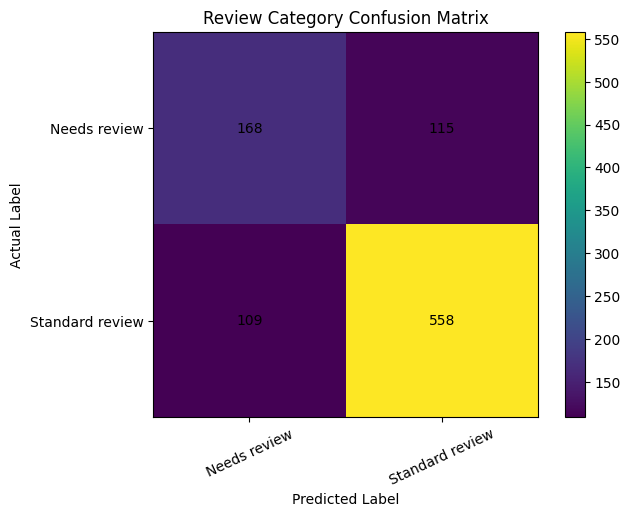

In [19]:
labels = review_model.classes_

cm = confusion_matrix(y_review_test, review_predictions, labels=labels)

plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.title("Review Category Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(range(len(labels)), labels, rotation=25)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

Original dataset shape: (4746, 12)
Original columns: ['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']

Cleaned dataset shape: (4746, 15)

Review category counts:
review_category
Standard review    3331
Needs review       1415
Name: count, dtype: int64


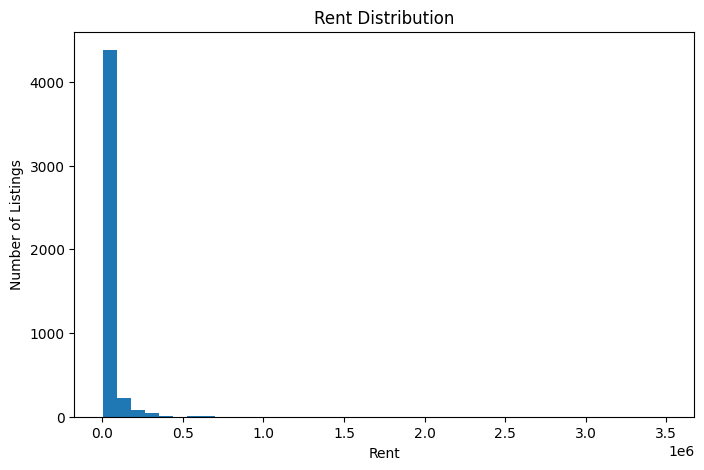

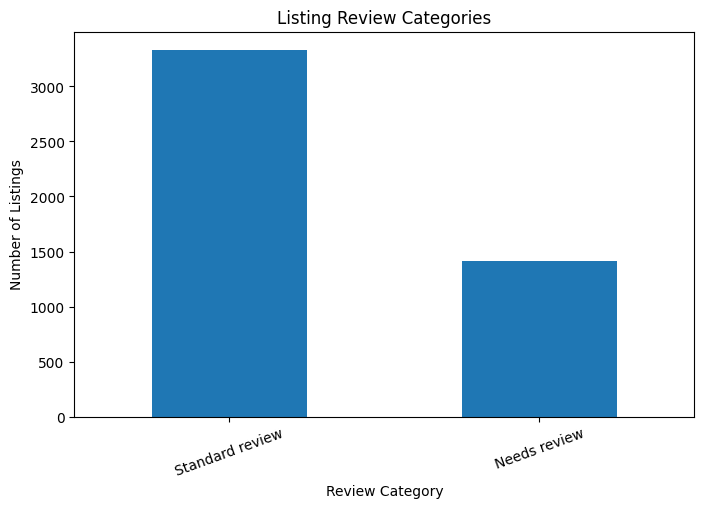

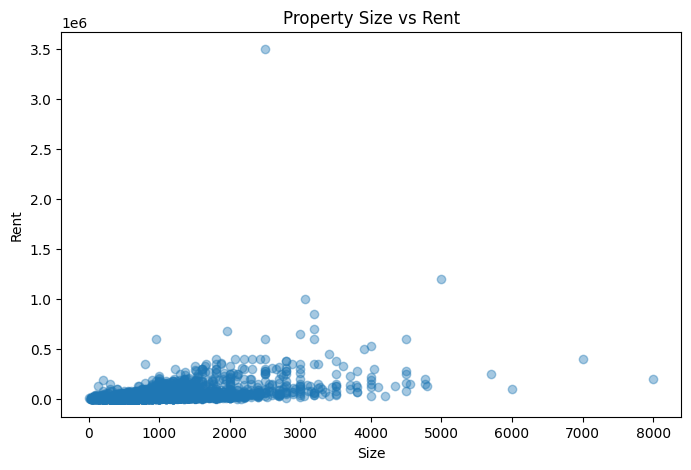


Training rows: 3796
Testing rows: 950
Model features: ['bhk', 'size', 'bathroom', 'completeness_score', 'city', 'area_type', 'furnishing_status', 'tenant_preferred', 'point_of_contact']

Rent Prediction Metrics
MAE: 12782.46
RMSE: 49303.65
R2 Score: -0.032

Review Classification Metrics
Accuracy: 0.764
Precision: 0.763
Recall: 0.764
F1 Score: 0.763

Classification Report:
                 precision    recall  f1-score   support

   Needs review       0.61      0.59      0.60       283
Standard review       0.83      0.84      0.83       667

       accuracy                           0.76       950
      macro avg       0.72      0.72      0.72       950
   weighted avg       0.76      0.76      0.76       950



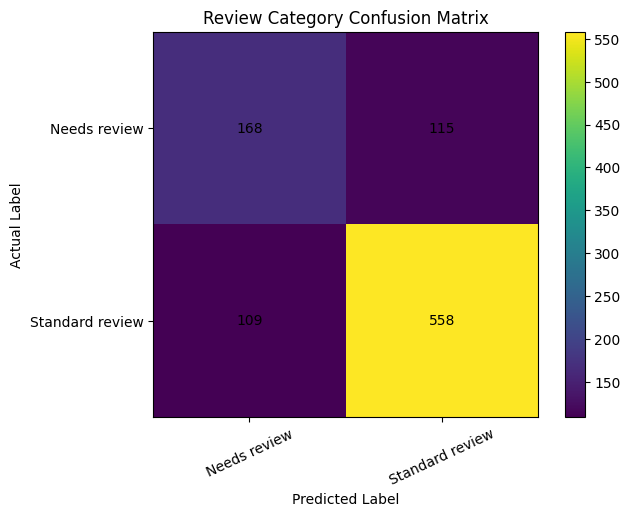


Export complete: noble_addis_kaggle_rental_predictions.csv


,city,area_locality,bhk,size,bathroom,rent,predicted_rent,predicted_rent_low,predicted_rent_high,review_category,predicted_review_category,completeness_score,furnishing_status,tenant_preferred,point_of_contact
0,Kolkata,Bandel,2,1100,2,10000,12491.948637,11242.753773,13741.143501,Needs review,Needs review,1.0,Unfurnished,Bachelors/Family,Contact Owner
1,Kolkata,"Phool Bagan, Kankurgachi",2,800,1,20000,11927.430700,10734.687630,13120.173770,Standard review,Needs review,1.0,Semi-Furnished,Bachelors/Family,Contact Owner
2,Kolkata,Salt Lake City Sector 2,2,1000,1,17000,10231.078144,9207.970330,11254.185958,Standard review,Needs review,1.0,Semi-Furnished,Bachelors/Family,Contact Owner
3,Kolkata,Dumdum Park,2,800,1,10000,7871.571231,7084.414107,8658.728354,Standard review,Needs review,1.0,Unfurnished,Bachelors/Family,Contact Owner
4,Kolkata,South Dum Dum,2,850,1,7500,8311.373389,7480.236050,9142.510728,Needs review,Needs review,1.0,Unfurnished,Bachelors,Contact Owner


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 1. Load dataset
df = pd.read_csv("/content/House_Rent_Dataset.csv")

print("Original dataset shape:", df.shape)
print("Original columns:", df.columns.tolist())

# 2. Clean column names
data = df.copy()

data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

data = data.drop_duplicates()

# 3. Convert numeric fields
data["rent"] = pd.to_numeric(data["rent"], errors="coerce")
data["size"] = pd.to_numeric(data["size"], errors="coerce")
data["bhk"] = pd.to_numeric(data["bhk"], errors="coerce")
data["bathroom"] = pd.to_numeric(data["bathroom"], errors="coerce")

data = data.dropna(subset=["rent", "size", "bhk", "bathroom"])

# 4. Feature engineering
data["rent_per_sqft"] = data["rent"] / data["size"].replace(0, np.nan)
data = data.dropna(subset=["rent_per_sqft"])

data["completeness_score"] = data[
    [
        "bhk",
        "rent",
        "size",
        "floor",
        "area_type",
        "area_locality",
        "city",
        "furnishing_status",
        "tenant_preferred",
        "bathroom",
        "point_of_contact",
    ]
].notna().mean(axis=1)

low_rent = data["rent_per_sqft"].quantile(0.15)
high_rent = data["rent_per_sqft"].quantile(0.85)

def assign_review_category(row):
    if row["completeness_score"] < 0.65:
        return "High review required"
    if row["rent_per_sqft"] > high_rent or row["rent_per_sqft"] < low_rent:
        return "Needs review"
    return "Standard review"

data["review_category"] = data.apply(assign_review_category, axis=1)

print("\nCleaned dataset shape:", data.shape)
print("\nReview category counts:")
print(data["review_category"].value_counts())

# 5. Visualizations
plt.figure(figsize=(8, 5))
plt.hist(data["rent"], bins=40)
plt.title("Rent Distribution")
plt.xlabel("Rent")
plt.ylabel("Number of Listings")
plt.show()

plt.figure(figsize=(8, 5))
data["review_category"].value_counts().plot(kind="bar")
plt.title("Listing Review Categories")
plt.xlabel("Review Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(data["size"], data["rent"], alpha=0.4)
plt.title("Property Size vs Rent")
plt.xlabel("Size")
plt.ylabel("Rent")
plt.show()

# 6. Model features
# Important: rent_per_sqft is NOT included as a model feature because it was used to create review_category.
features = [
    "bhk",
    "size",
    "bathroom",
    "completeness_score",
    "city",
    "area_type",
    "furnishing_status",
    "tenant_preferred",
    "point_of_contact",
]

target_regression = "rent"
target_classification = "review_category"

model_data = data[features + [target_regression, target_classification]].copy()

X = model_data[features]
y_rent = model_data[target_regression]
y_review = model_data[target_classification]

X_train, X_test, y_rent_train, y_rent_test, y_review_train, y_review_test = train_test_split(
    X,
    y_rent,
    y_review,
    test_size=0.2,
    random_state=42,
    stratify=y_review
)

print("\nTraining rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Model features:", X_train.columns.tolist())

# 7. Preprocessing
categorical_features = [
    "city",
    "area_type",
    "furnishing_status",
    "tenant_preferred",
    "point_of_contact",
]

numeric_features = [
    "bhk",
    "size",
    "bathroom",
    "completeness_score",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features),
    ]
)

# 8. Rent prediction model
rent_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=150,
            max_depth=12,
            random_state=42
        )),
    ]
)

rent_model.fit(X_train, y_rent_train)

rent_predictions = rent_model.predict(X_test)

mae = mean_absolute_error(y_rent_test, rent_predictions)
rmse = np.sqrt(mean_squared_error(y_rent_test, rent_predictions))
r2 = r2_score(y_rent_test, rent_predictions)

print("\nRent Prediction Metrics")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 3))

# 9. Review category model
review_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            random_state=42,
            class_weight="balanced"
        )),
    ]
)

review_model.fit(X_train, y_review_train)

review_predictions = review_model.predict(X_test)

accuracy = accuracy_score(y_review_test, review_predictions)
precision = precision_score(y_review_test, review_predictions, average="weighted")
recall = recall_score(y_review_test, review_predictions, average="weighted")
f1 = f1_score(y_review_test, review_predictions, average="weighted")

print("\nReview Classification Metrics")
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

print("\nClassification Report:")
print(classification_report(y_review_test, review_predictions))

# 10. Confusion matrix
labels = review_model.classes_
cm = confusion_matrix(y_review_test, review_predictions, labels=labels)

plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.title("Review Category Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(range(len(labels)), labels, rotation=25)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

# 11. Create prediction export
model_predictions = data.copy()

prediction_features = model_predictions[features]

model_predictions["predicted_rent"] = rent_model.predict(prediction_features)
model_predictions["predicted_review_category"] = review_model.predict(prediction_features)

model_predictions["predicted_rent_low"] = model_predictions["predicted_rent"] * 0.9
model_predictions["predicted_rent_high"] = model_predictions["predicted_rent"] * 1.1

export_columns = [
    "city",
    "area_locality",
    "bhk",
    "size",
    "bathroom",
    "rent",
    "predicted_rent",
    "predicted_rent_low",
    "predicted_rent_high",
    "review_category",
    "predicted_review_category",
    "completeness_score",
    "furnishing_status",
    "tenant_preferred",
    "point_of_contact",
]

model_predictions[export_columns].to_csv(
    "noble_addis_kaggle_rental_predictions.csv",
    index=False
)

print("\nExport complete: noble_addis_kaggle_rental_predictions.csv")

model_predictions[export_columns].head()

In [24]:
from google.colab import files

files.download("noble_addis_kaggle_rental_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Larger Dataset Training Note

The first Noble Addis MVP model was trained using a small scraped listing dataset. While waiting for more Addis Ababa-specific property data, this notebook uses a larger Kaggle rental dataset with over 4,700 entries to test the machine learning pipeline with more training examples.

This dataset is not presented as the final Addis Ababa market dataset. It is used temporarily to validate the workflow for data cleaning, feature engineering, visualization, model training, model evaluation, and prediction export. Once the requested local data is received, the same pipeline can be retrained using Addis-specific property data.